# Load the model file

In [2]:
import pandas as pd

# Path to the data file
file_path = "F10_Mod.txt"

# Define the column names manually
columns = ["X", "Y", "Z", "sx", "sy", "sz", "density", "sen", "ord"]

# Read the file:
# - skiprows=2 skips the first 2 lines (metadata line + header line)
# - sep=r'\s+' handles variable whitespace separation
# - names=columns explicitly assigns column names
# - usecols=range(9) ensures we only load the 9 main columns
df = pd.read_csv(
    file_path,
    skiprows=2,
    sep=r'\s+',
    names=columns,
    usecols=range(9)
)

# Display result summary
print("DataFrame columns:", df.columns.tolist())
df

DataFrame columns: ['X', 'Y', 'Z', 'sx', 'sy', 'sz', 'density', 'sen', 'ord']


,X,Y,Z,sx,sy,sz,density,sen,ord
0,337420,3128091,2757,436,263,436,-178.2,26.0,-18.4
1,337855,3128038,2757,436,158,436,-178.2,15.6,-19.1
2,337855,3128223,2757,436,212,436,-178.2,22.4,-19.3
3,337855,3128517,2757,436,376,436,-178.2,39.9,-19.0
4,338291,3127272,2757,436,368,436,-178.2,38.9,-19.2
...,...,...,...,...,...,...,...,...,...
93191,349867,3181782,-27838,3286,1598,3286,0.0,9475.8,-999.0
93192,353153,3074700,-27838,3286,1706,3286,0.0,9807.3,-999.0
93193,382730,3094405,-27838,3286,1681,3286,0.0,9631.8,-999.0
93194,386016,3168880,-27838,3286,1302,3286,0.0,7677.2,-999.0


# Plotting the model

## Depth Z slice

makecpt [WARNING]: Without inc in -T option, -Z has no effect (ignored)


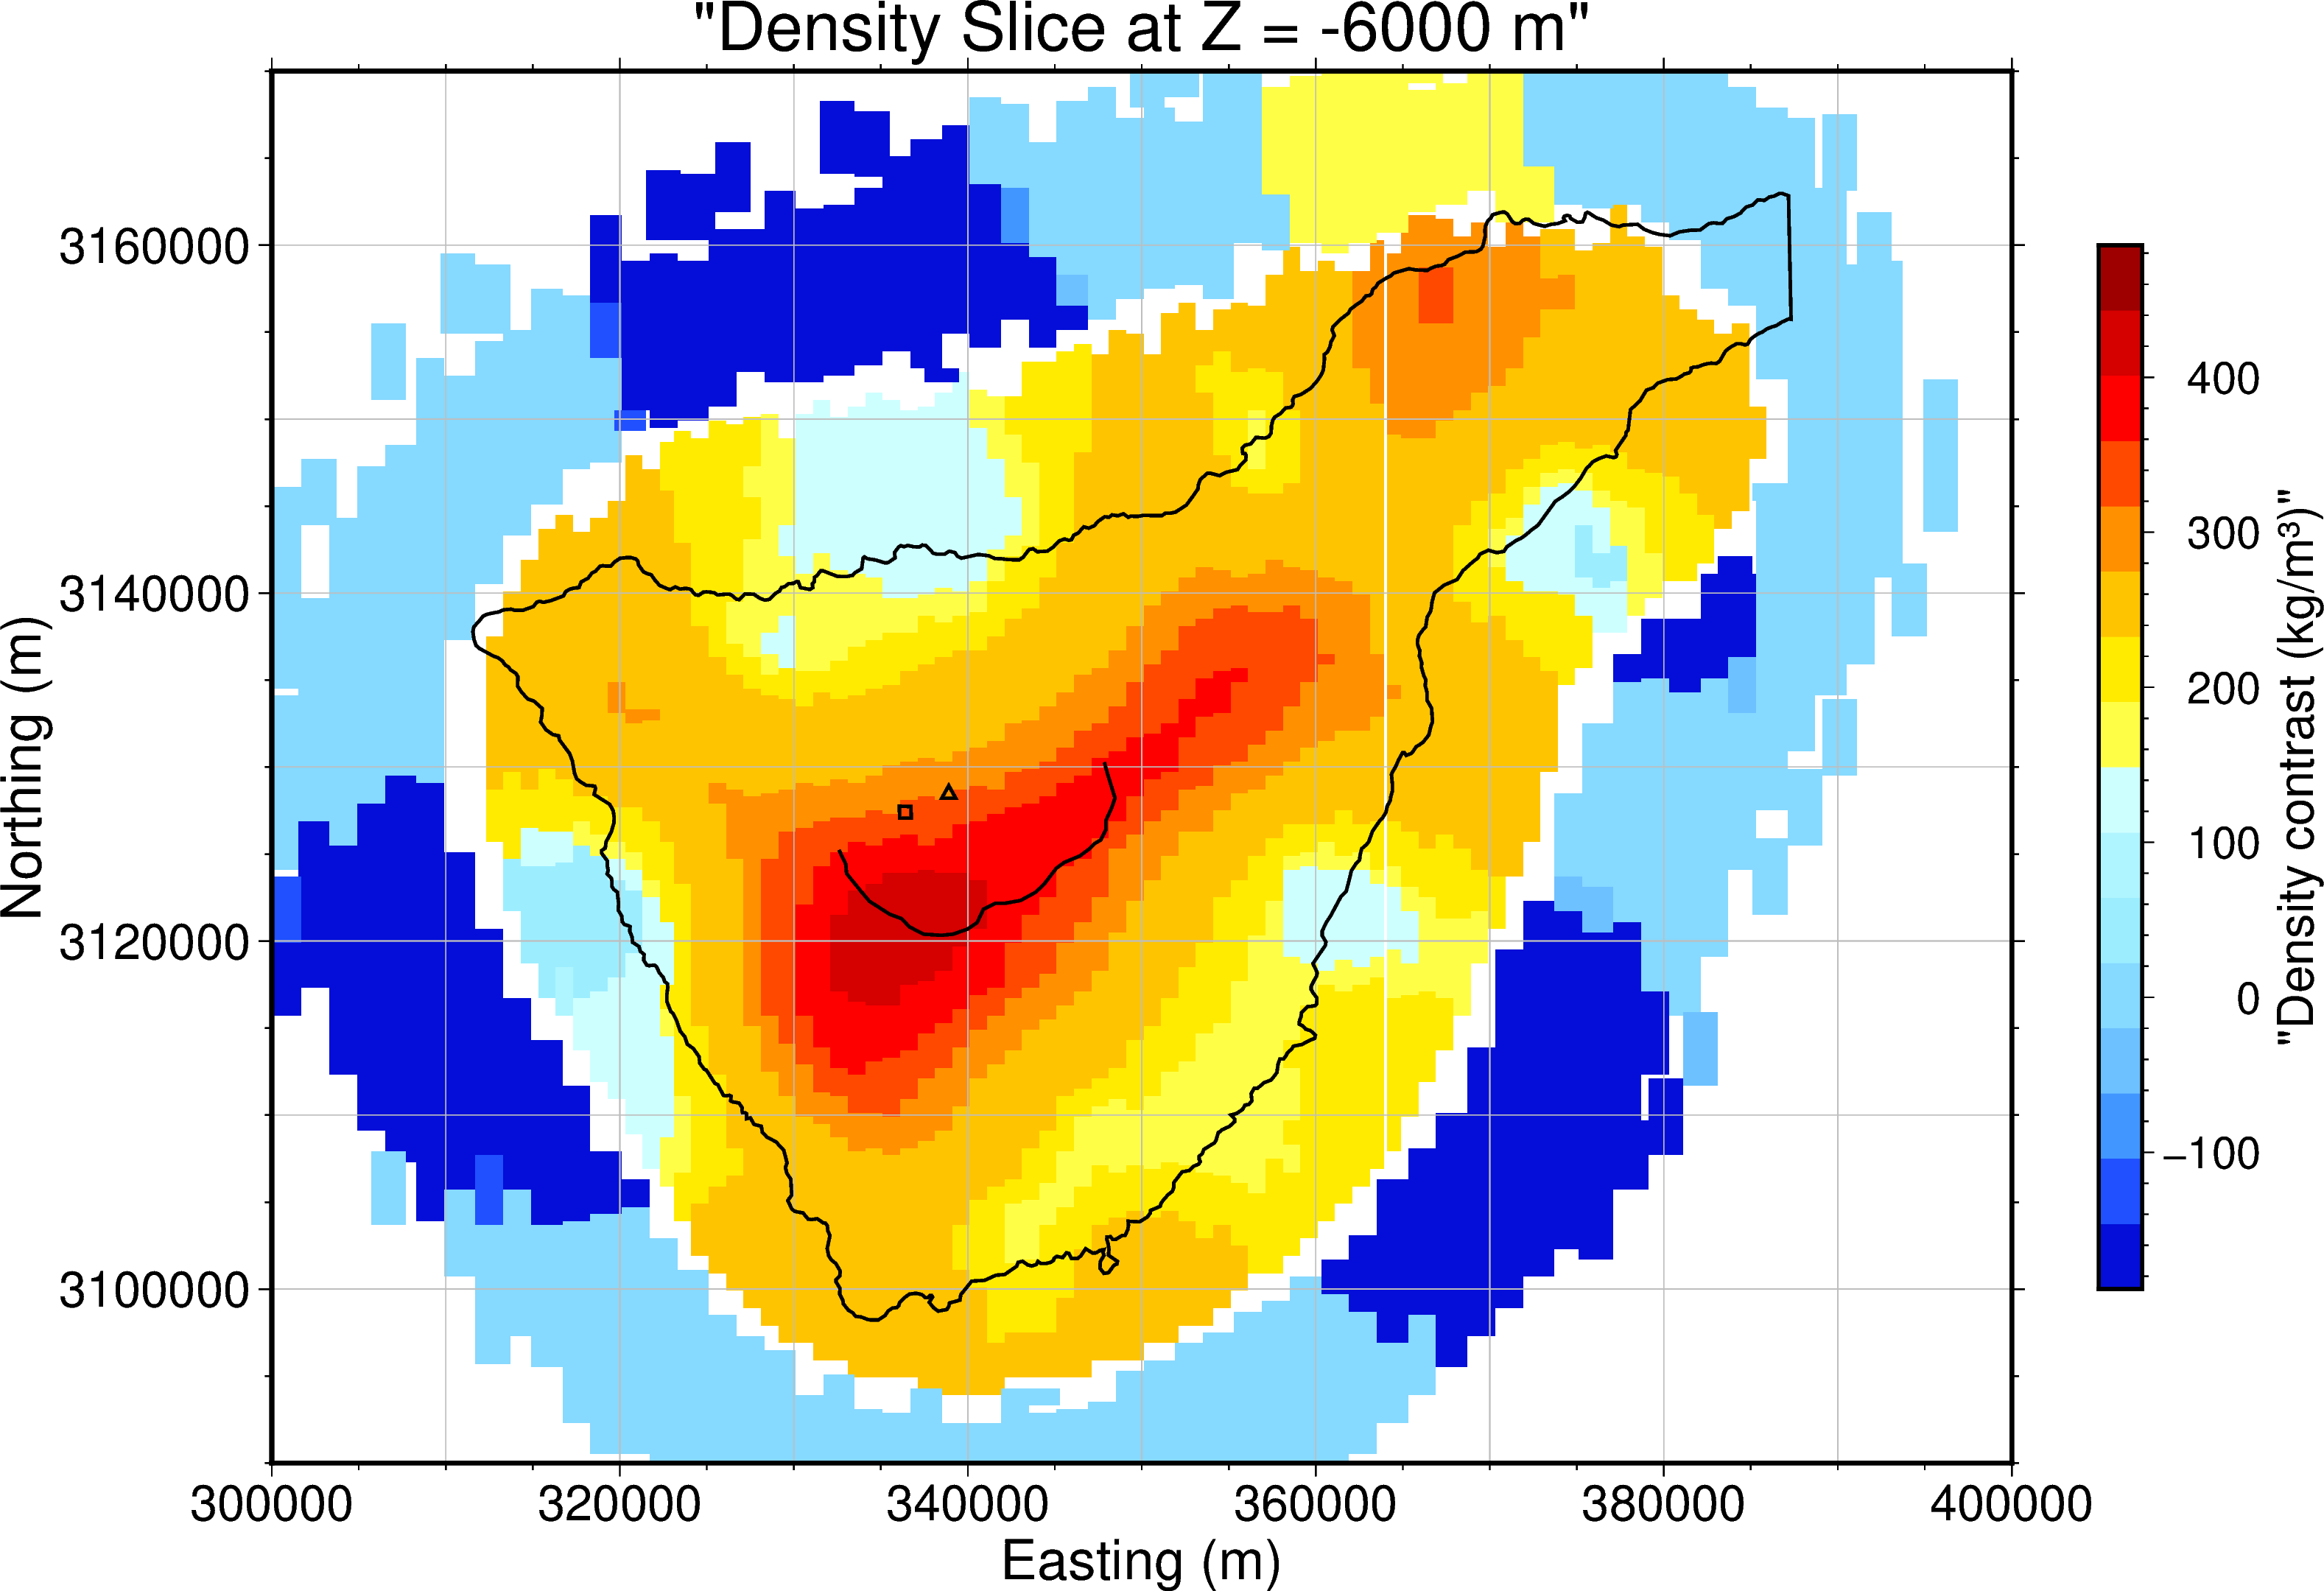

In [12]:
import numpy as np
import pandas as pd
import pygmt
import xarray as xr

# =============================================================================
# CONFIGURATION & PARAMETERS
# =============================================================================
TARGET_Z_M = -6000      # Target Z level in meters (asl)
VOXEL_DX = 200      # Voxel resolution X in meters
VOXEL_DY = 200      # Voxel resolution Y in meters

# Map Region covering Tenerife (UTM Zone 28N coordinates)
REGION_UTM = [300000, 400000, 3090000, 3170000]

# Global density scale limits based on the ENTIRE 3D model dataset (df)
DEN_MIN = df["density"].min() - 10
DEN_MAX = df["density"].max() + 10

OUTPUT_FILENAME = f"Density_Z_{TARGET_Z_M}m.png"
BLN_FILE = "map.bln"  # Path to the .bln file with the coastline and structures

# =============================================================================
# FUNCTION TO LOAD .BLN FILE
# =============================================================================
def load_bln(bln_path):
    polygons = []
    with open(bln_path, "r") as f:
        lines = f.readlines()

    idx = 0
    while idx < len(lines):
        line = lines[idx].strip()
        if not line:
            idx += 1
            continue
        parts = line.replace(",", " ").split()
        if len(parts) >= 1:
            try:
                n_points = int(parts[0])
                idx += 1
                pts = []
                for _ in range(n_points):
                    if idx < len(lines):
                        coord_parts = lines[idx].strip().replace(",", " ").split()
                        if len(coord_parts) >= 2:
                            pts.append([float(coord_parts[0]), float(coord_parts[1])])
                        idx += 1
                if pts:
                    polygons.append(pd.DataFrame(pts, columns=["X", "Y"]))
            except ValueError:
                idx += 1
    return polygons

# =============================================================================
# 1. 3D VOXELIZATION
# =============================================================================
df["X_min"] = df["X"] - (df["sx"] / 2.0)
df["X_max"] = df["X"] + (df["sx"] / 2.0)
df["Y_min"] = df["Y"] - (df["sy"] / 2.0)
df["Y_max"] = df["Y"] + (df["sy"] / 2.0)
df["Z_min"] = df["Z"] - (df["sz"] / 2.0)
df["Z_max"] = df["Z"] + (df["sz"] / 2.0)

# Filter all cells that intersect the TARGET_Z_M horizontal plane
intersecting_cells = df[
    (df["Z_min"] <= TARGET_Z_M) & (df["Z_max"] >= TARGET_Z_M)
].copy()

# Create regular 2D voxel grid coordinates
x_coords = np.arange(REGION_UTM[0], REGION_UTM[1] + VOXEL_DX, VOXEL_DX)
y_coords = np.arange(REGION_UTM[2], REGION_UTM[3] + VOXEL_DY, VOXEL_DY)
grid_x, grid_y = np.meshgrid(x_coords, y_coords)

# Initialize grid with NaN
density_grid_data = np.full(grid_x.shape, np.nan)

# Fill voxels by testing point inclusion in intersecting prisms
for _, row in intersecting_cells.iterrows():
    mask = (
        (grid_x >= row["X_min"]) & (grid_x <= row["X_max"]) &
        (grid_y >= row["Y_min"]) & (grid_y <= row["Y_max"])
    )
    density_grid_data[mask] = row["density"]

# Convert to xarray.DataArray for PyGMT compatibility
grid_xr = xr.DataArray(
    density_grid_data,
    coords={"y": y_coords, "x": x_coords},
    dims=["y", "x"]
)

# =============================================================================
# 2. PYGMT PLOTTING
# =============================================================================
fig = pygmt.Figure()

# Custom PyGMT style configuration
pygmt.config(
    FONT_ANNOT_PRIMARY="16p,Helvetica,black",
    FONT_LABEL="18p,Helvetica,black",
    FONT_TITLE="22p,Helvetica,black",
    MAP_TITLE_OFFSET="0.1c",
    MAP_GRID_PEN="0.3p,gray"
)

# Create color palette centered on density values
pygmt.makecpt(
    cmap="panoply",
    series=[DEN_MIN, DEN_MAX],
    continuous=True,
)

# Plot voxelized raster image
fig.grdimage(
    grid=grid_xr,
    region=REGION_UTM,
    projection="x1:500000",
    frame=[
        "pxa20000f5000g10000+lEasting (m)",    
        "pya20000f5000g10000+lNorthing (m)",   
        f'WSen+t"Density Slice at Z = {TARGET_Z_M} m"',
    ],
    cmap=True,
    nan_transparent=True
)

# --- OVERLAY .BLN FILE ---
bln_polygons = load_bln(BLN_FILE)
for poly_df in bln_polygons:
    fig.plot(
        x=poly_df["X"],
        y=poly_df["Y"],
        pen="1p,black",
        region=REGION_UTM,
        projection="x1:500000",
    )

# Add vertical colorbar on the right side
fig.colorbar(
    frame=['a100f20', 'x+l"Density contrast (kg/m\u00b3)"'],
    position="JMR+o1.0c/0c+w12c/0.5c",
)

# Display figure
fig.savefig(OUTPUT_FILENAME)
fig.show()

## Vertical X profile

makecpt [WARNING]: Without inc in -T option, -Z has no effect (ignored)


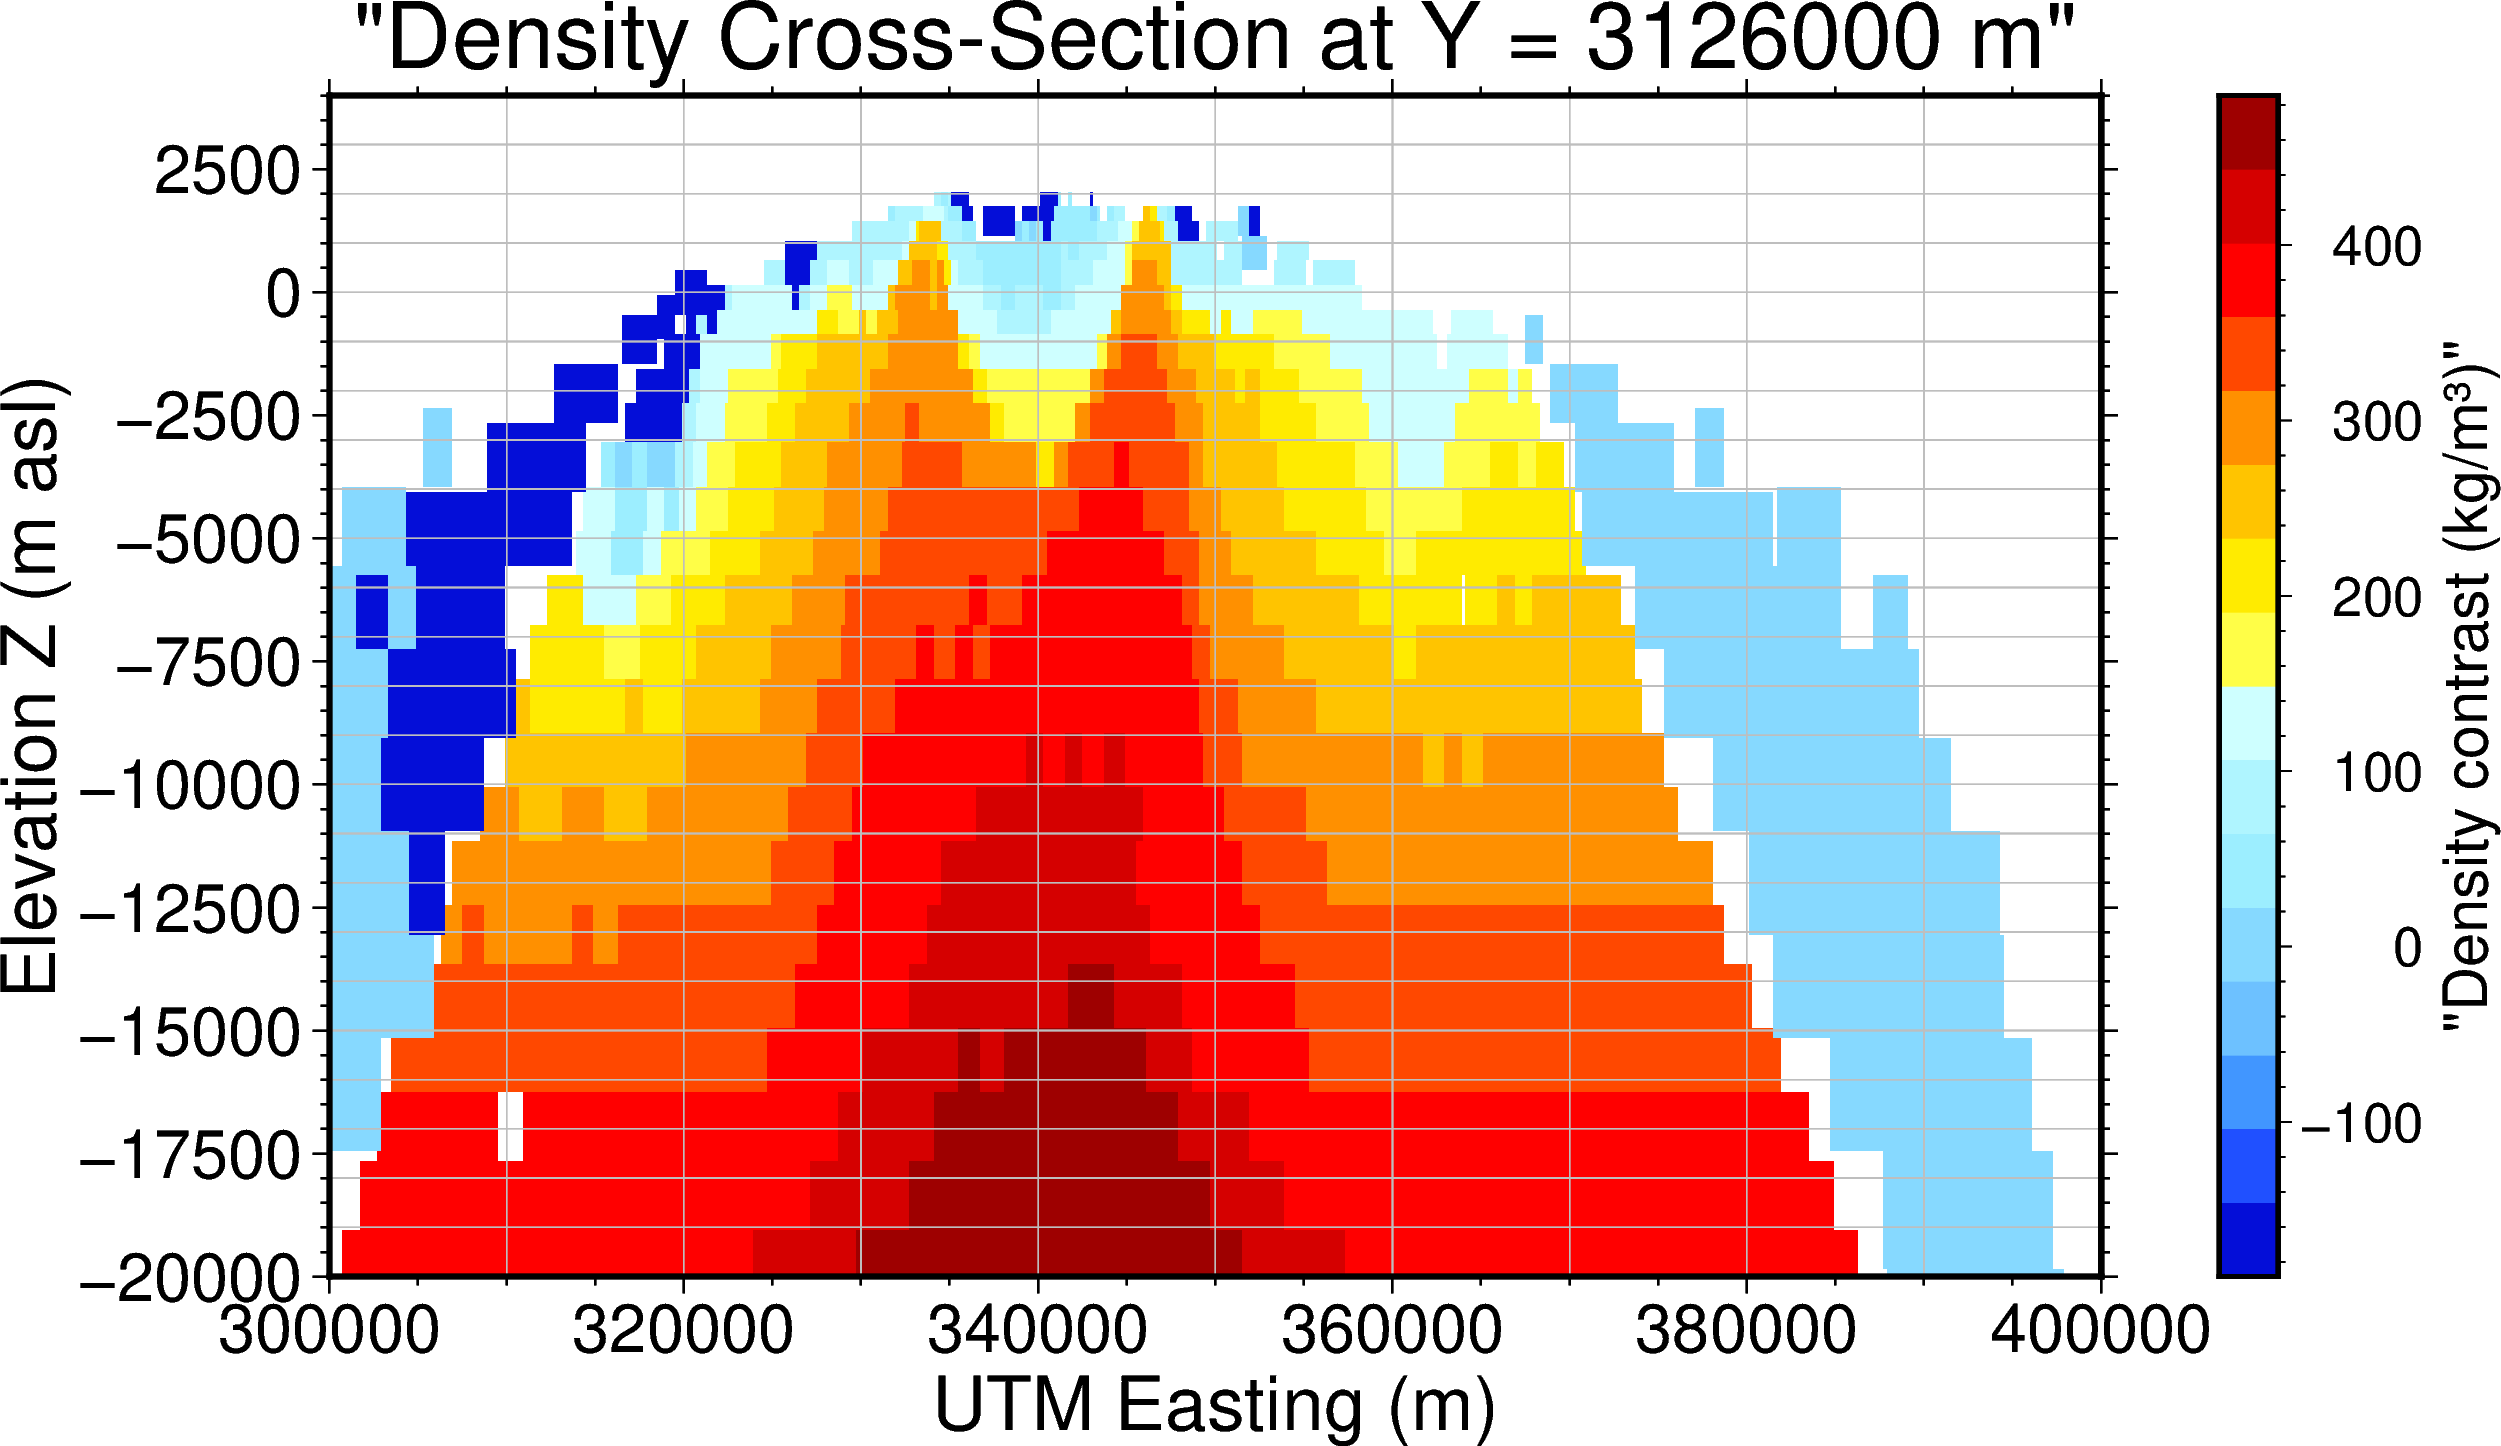

In [31]:
import numpy as np
import pandas as pd
import pygmt
import xarray as xr

# =============================================================================
# CONFIGURATION & PARAMETERS FOR X-PROFILE (X vs Z at fixed Y)
# =============================================================================
TARGET_Y_M = 3126000     # Target Y position in UTM meters (Northing)
VOXEL_DX = 200          # Horizontal voxel resolution (m)
VOXEL_DZ = 100          # Vertical voxel resolution (m)

# Profile Region [Xmin, Xmax, Zmin, Zmax]
# Adjust Z range based on your model limits (e.g. from -5000 m to +3700 m)
REGION_PROFILE = [300000, 400000, -20000, 4000]

# Global density scale limits based on the ENTIRE 3D model dataset (df)
DEN_MIN = df["density"].min() - 10
DEN_MAX = df["density"].max() + 10

OUTPUT_FILENAME = f"Density_Profile_Y_{TARGET_Y_M}m.png"

# =============================================================================
# 1. 3D VOXELIZATION ALONG Y PLANE
# =============================================================================
# Ensure 3D cell boundaries exist
df["X_min"] = df["X"] - (df["sx"] / 2.0)
df["X_max"] = df["X"] + (df["sx"] / 2.0)
df["Y_min"] = df["Y"] - (df["sy"] / 2.0)
df["Y_max"] = df["Y"] + (df["sy"] / 2.0)
df["Z_min"] = df["Z"] - (df["sz"] / 2.0)
df["Z_max"] = df["Z"] + (df["sz"] / 2.0)

# Filter cells intersecting the vertical TARGET_Y_M plane
intersecting_cells = df[
    (df["Y_min"] <= TARGET_Y_M) & (df["Y_max"] >= TARGET_Y_M)
].copy()

# Create regular 2D vertical voxel grid coordinates (X vs Z)
x_coords = np.arange(REGION_PROFILE[0], REGION_PROFILE[1] + VOXEL_DX, VOXEL_DX)
z_coords = np.arange(REGION_PROFILE[2], REGION_PROFILE[3] + VOXEL_DZ, VOXEL_DZ)
grid_x, grid_z = np.meshgrid(x_coords, z_coords)

# Initialize grid with NaN
density_grid_data = np.full(grid_x.shape, np.nan)

# Fill voxels by testing point inclusion in intersecting prisms
for _, row in intersecting_cells.iterrows():
    mask = (
        (grid_x >= row["X_min"]) & (grid_x <= row["X_max"]) &
        (grid_z >= row["Z_min"]) & (grid_z <= row["Z_max"])
    )
    density_grid_data[mask] = row["density"]

# Convert to xarray.DataArray for PyGMT
grid_xr = xr.DataArray(
    density_grid_data,
    coords={"z": z_coords, "x": x_coords},
    dims=["z", "x"]
)

# =============================================================================
# 2. PYGMT PLOTTING
# =============================================================================
fig = pygmt.Figure()

# Custom PyGMT style configuration
pygmt.config(
    FONT_ANNOT_PRIMARY="16p,Helvetica,black",
    FONT_LABEL="18p,Helvetica,black",
    FONT_TITLE="22p,Helvetica,black",
    MAP_TITLE_OFFSET="0.1c",
    MAP_GRID_PEN="0.3p,gray",
)

# Create color palette centered on density values
pygmt.makecpt(
    cmap="panoply",
    series=[DEN_MIN, DEN_MAX],
    continuous=True,
)

# Plot voxelized vertical raster section
# Note: Cartesian projection "X15c/10c" sets fixed width=15cm, height=10cm
fig.grdimage(
    grid=grid_xr,
    region=REGION_PROFILE,
    projection="X15c/10c",
    frame=[
        "pxa20000f5000g10000+lUTM Easting (m)",
        "pya2500f500g1000+lElevation Z (m asl)",
        f'WSen+t"Density Cross-Section at Y = {TARGET_Y_M} m"',
    ],
    cmap=True,
    nan_transparent=True,
)

# Add vertical colorbar on the right side
fig.colorbar(
    frame=['a100f20', 'x+l"Density contrast (kg/m\u00b3)"'],
    position="JMR+o1.0c/0c+w10c/0.5c",
)

# Display figure
fig.savefig(OUTPUT_FILENAME)
fig.show()